# Newfoundland & Labrador Birding Overview
A static infographic of bird observations, summarizing rarity, seasons, and location hotspots.

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from matplotlib.lines import Line2D

df = pd.read_csv('birds.csv')
df['OBSERVATION DATE'] = pd.to_datetime(df['OBSERVATION DATE'])
df['Month'] = df['OBSERVATION DATE'].dt.month
df['OBSERVATION COUNT'] = pd.to_numeric(df['OBSERVATION COUNT'], errors='coerce').fillna(1)

print(f"Loaded {len(df):,} rows")

# IBA CODE being present = inside a protected area
df['Protected Area Status'] = df['IBA CODE'].apply(
    lambda x: 'Inside Protected Area' if pd.notnull(x) else 'Outside Protected Area'
)

# rarity score: invert percentile rank so rare species score near 100
species_totals = df.groupby('COMMON NAME')['OBSERVATION COUNT'].sum()
rarity_score_map = 100 - species_totals.rank(pct=True) * 100
df['Rarity Score'] = df['COMMON NAME'].map(rarity_score_map).round(2)

# -0.001 on the lower bound avoids pd.cut dropping rows that land exactly on the min
df['Rarity Tier'] = pd.cut(
    df['Rarity Score'],
    bins=[-0.001, 24.999, 49.999, 74.999, 94.999, 100.0],
    labels=['Abundant', 'Common', 'Uncommon', 'Rare', 'Ultra-Rare']
).astype(str)

tier_colors = {
    'Ultra-Rare': '#8E44AD', 'Rare':     '#E74C3C',
    'Uncommon':   '#E67E22', 'Common':   '#27AE60', 'Abundant': '#3498DB',
}
tier_order = ['Ultra-Rare', 'Rare', 'Uncommon', 'Common', 'Abundant']

species_summary = df.groupby('COMMON NAME').agg(
    Rarity_Score=('Rarity Score', 'first'),
    Rarity_Tier=('Rarity Tier', 'first'),
).reset_index().sort_values('Rarity_Score', ascending=False)

# species for the seasonal line chart - tried to pick a mix of common + one rare
base_birds_wanted = ['American Goldfinch', 'American Robin', 'Dark-eyed Junco',
                     'Common Eider', 'Herring Gull']
available_set = set(df['COMMON NAME'].unique())
base_birds = [b for b in base_birds_wanted if b in available_set]

# fill in from most-observed if any of the above aren't in the dataset
if len(base_birds) < 5:
    extras = (species_totals.drop(labels=base_birds, errors='ignore')
                .sort_values(ascending=False).index.tolist())
    base_birds += extras[:5 - len(base_birds)]

# pick one Rare species that shows up in at least 4 months (more interesting line)
rare_cands = species_summary[species_summary['Rarity_Tier'] == 'Rare']['COMMON NAME'].tolist()
rare_pick = next(
    (c for c in rare_cands if df[df['COMMON NAME'] == c]['Month'].nunique() >= 4),
    rare_cands[0] if rare_cands else None
)
target_birds = base_birds + ([rare_pick] if rare_pick else [])

seasonal_data = df[df['COMMON NAME'].isin(target_birds)]
seasonal_summary = (seasonal_data.groupby(['Month', 'COMMON NAME'])['OBSERVATION COUNT']
                                 .sum().unstack().fillna(0))

iba_rarity = df.groupby(['Protected Area Status', 'Rarity Tier'])['OBSERVATION COUNT'].sum().unstack().fillna(0)
ordered_tiers = [t for t in tier_order if t in iba_rarity.columns]
iba_rarity = iba_rarity[ordered_tiers]

# summary stats used in chart annotations and header pills
_mtot = df.groupby('Month')['OBSERVATION COUNT'].sum()
PEAK_MONTH_IDX = int(_mtot.idxmax())
PEAK_MONTH_NAME = ['January','February','March','April','May','June',
                   'July','August','September','October','November','December'][PEAK_MONTH_IDX - 1]
PEAK_MONTH_OBS = int(_mtot.max())

_ur = df[df['Rarity Tier'] == 'Ultra-Rare']
ULTRA_RARE_IBA_PCT = round(
    _ur[_ur['Protected Area Status'] == 'Inside Protected Area']['OBSERVATION COUNT'].sum()
    / max(_ur['OBSERVATION COUNT'].sum(), 1) * 100
)

_ab = df[df['Rarity Tier'] == 'Abundant']
_ab_rate = (_ab[_ab['Protected Area Status'] == 'Inside Protected Area']['OBSERVATION COUNT'].sum()
            / max(_ab['OBSERVATION COUNT'].sum(), 1))
_ur_rate = ULTRA_RARE_IBA_PCT / 100
IBA_MULTIPLIER = round(_ur_rate / max(_ab_rate, 1e-9), 1)

TOP_COUNTY = (df.groupby('COUNTY')['OBSERVATION COUNT']
              .sum().sort_values(ascending=False).index[0])
TOP_COUNTY_SHARE = round(
    df[df['COUNTY'] == TOP_COUNTY]['OBSERVATION COUNT'].sum()
    / df['OBSERVATION COUNT'].sum() * 100
)

OBS_WINDOW = f"{df['OBSERVATION DATE'].min():%b %Y} - {df['OBSERVATION DATE'].max():%b %Y}"
TOTAL_REC = len(df)
UNIQUE_SPECIES = int(df['COMMON NAME'].nunique())
IBA_SIGHTINGS = int(df['IBA CODE'].notna().sum())

print(f"Peak month: {PEAK_MONTH_NAME} | Top county: {TOP_COUNTY} ({TOP_COUNTY_SHARE}%)")
print(f"Ultra-rare inside protected areas: {ULTRA_RARE_IBA_PCT}% | multiplier vs abundant: {IBA_MULTIPLIER}x")

Loaded 308,370 rows
Peak month: June | Top county: Avalon Peninsula-St. John's (94%)
Ultra-rare inside protected areas: 9% | multiplier vs abundant: 0.1x


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


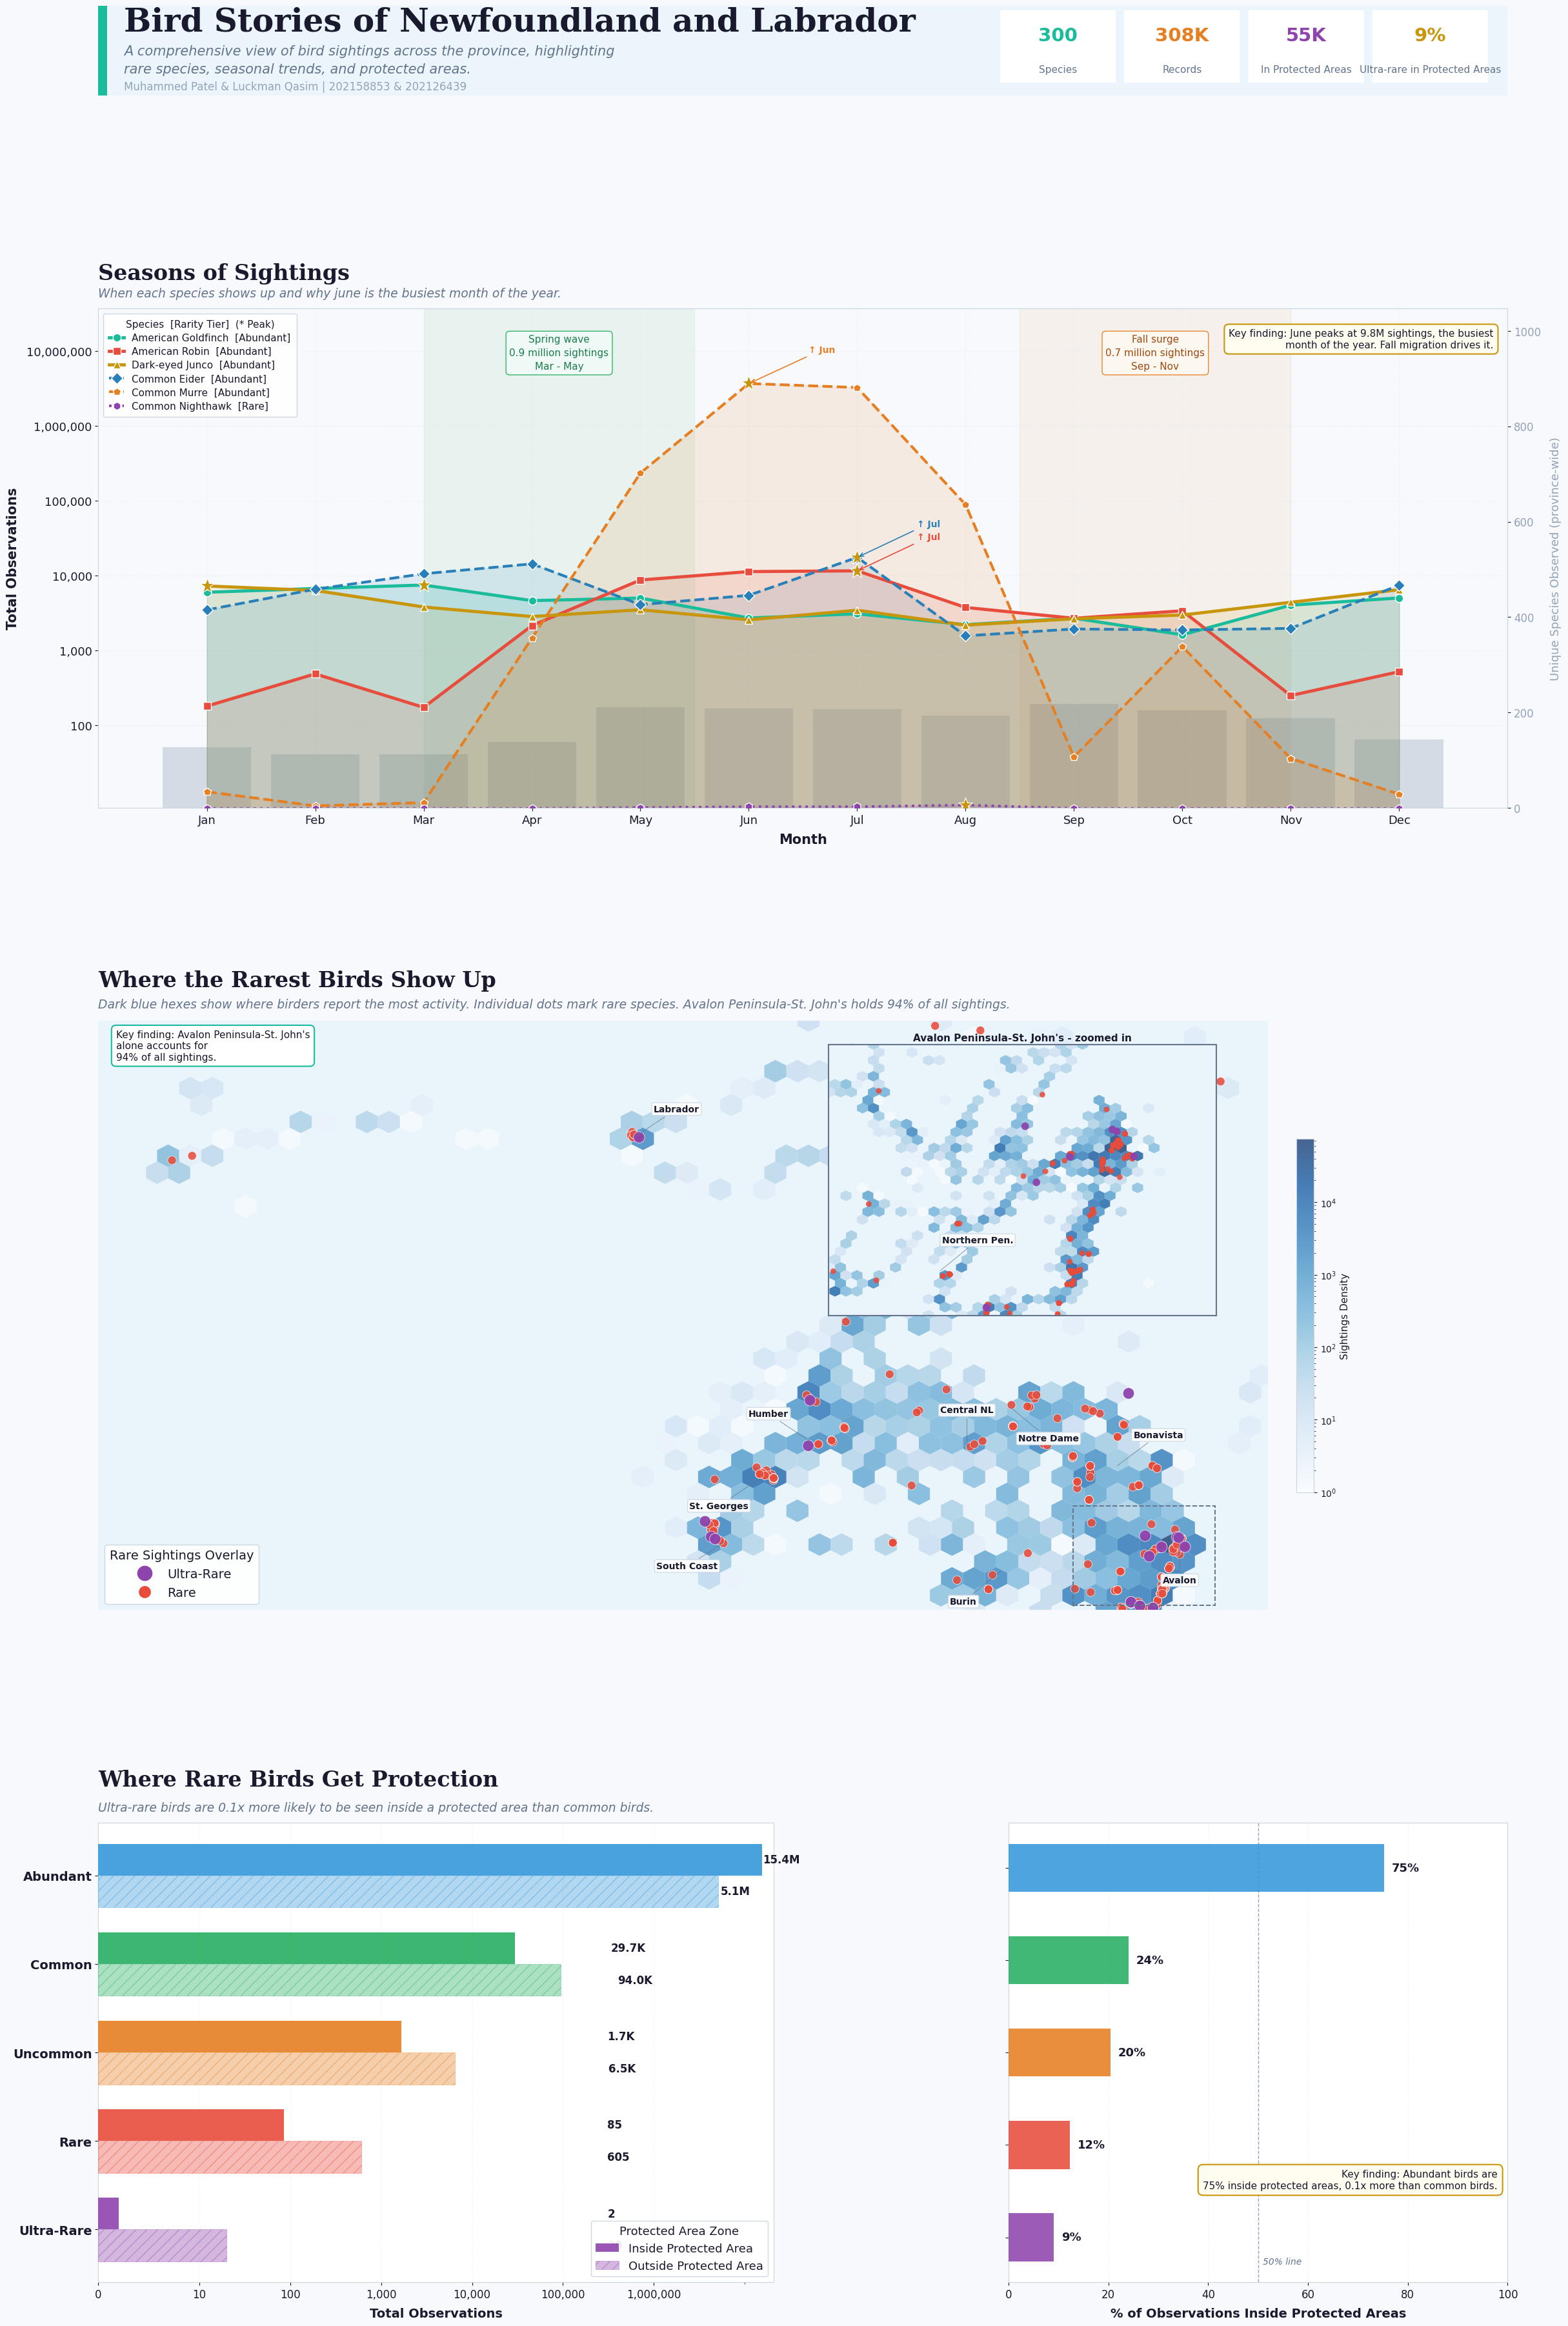

saved to infographic_output.png


In [7]:
BG    = '#F7F9FC'
PANEL = '#FFFFFF'
TEXT  = '#1A1A2E'
MUTED = '#64748B'
ACCENT = '#1ABC9C'
GOLD  = '#C8960C'

plt.rcParams.update({
    'text.color':        TEXT,
    'axes.labelcolor':   TEXT,
    'xtick.color':       TEXT,
    'ytick.color':       TEXT,
    'axes.edgecolor':    '#CBD5E0',
    'grid.color':        '#E2E8F0',
    'legend.facecolor':  '#FFFFFF',
    'legend.edgecolor':  '#CBD5E0',
    'legend.labelcolor': TEXT,
})

fig = plt.figure(figsize=(24, 36), facecolor=BG)

# 4 rows: header, seasonal line, map, conservation bars
gs = fig.add_gridspec(
    4, 1,
    height_ratios=[0.18, 1.00, 1.18, 0.92],
    hspace=0.52,
    top=0.992, bottom=0.012,
    left=0.055, right=0.965,
)

month_ticks = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

TITLE_KW    = dict(fontsize=24, fontweight='bold', color=TEXT, family='serif', va='bottom', wrap=True)
SUBTITLE_KW = dict(fontsize=13.5, color=MUTED, fontstyle='italic', va='bottom', wrap=True)
FINDING_KW  = dict(fontsize=11, color=TEXT)

# HEADER 
ax_hdr = fig.add_subplot(gs[0])
ax_hdr.set_facecolor('#EBF5FB')
ax_hdr.set_xlim(0, 1)
ax_hdr.set_ylim(0, 1)
for sp in ax_hdr.spines.values():
    sp.set_visible(False)
ax_hdr.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

# left accent bar
ax_hdr.add_patch(plt.Rectangle((0, 0), 0.006, 1,
                                facecolor=ACCENT, transform=ax_hdr.transAxes, zorder=5))

ax_hdr.text(0.018, 0.82, 'Bird Stories of Newfoundland and Labrador',
            transform=ax_hdr.transAxes,
            fontsize=36, fontweight='bold', color=TEXT,
            family='serif', va='center', zorder=6)

ax_hdr.text(0.018, 0.4,
            f'A comprehensive view of bird sightings across the province, highlighting\n'
            f'rare species, seasonal trends, and protected areas.',
            transform=ax_hdr.transAxes,
            fontsize=15, color=MUTED, fontstyle='italic', va='center', zorder=6, linespacing=1.5)

ax_hdr.text(0.018, 0.1,
            f'Muhammed Patel & Luckman Qasim | 202158853 & 202126439',
            transform=ax_hdr.transAxes,
            fontsize=12, color='#94A3B8', va='center', zorder=6)

# stat pills in the top-right corner
pills = [
    (f'{UNIQUE_SPECIES:,}',          'Species',                      ACCENT),
    (f'{TOTAL_REC/1e3:.0f}K',        'Records',                      '#E67E22'),
    (f'{IBA_SIGHTINGS/1e3:.0f}K',    'In Protected Areas',           '#8E44AD'),
    (f'{int(ULTRA_RARE_IBA_PCT)}%',  'Ultra-rare in Protected Areas', GOLD),
]
for i, (val, lbl, clr) in enumerate(pills):
    x = 0.640 + i * 0.088
    ax_hdr.add_patch(plt.Rectangle((x, 0.15), 0.082, 0.80,
                                    facecolor='#FFFFFF', transform=ax_hdr.transAxes,
                                    zorder=4, linewidth=0))
    ax_hdr.text(x + 0.041, 0.67, val, transform=ax_hdr.transAxes,
                fontsize=21, fontweight='bold', color=clr,
                ha='center', va='center', zorder=6)
    ax_hdr.text(x + 0.041, 0.29, lbl, transform=ax_hdr.transAxes,
                fontsize=11, color=MUTED, ha='center', va='center', zorder=6)

# CHART 1: SEASONAL LINES
ax1 = fig.add_subplot(gs[1])
ax1.set_facecolor(PANEL)

line_colours = ['#1ABC9C', '#E74C3C', '#C8960C', '#2980B9', '#E67E22', '#8E44AD']
line_styles  = ['-', '-', '-', '--', '--', ':']
line_widths  = [3.5, 3.5, 3.5, 3.0, 3.0, 2.8]
markers      = ['o', 's', '^', 'D', 'p', 'h']

# gray bars in background = total species diversity per month
ax1b = ax1.twinx()
species_per_month = df.groupby('Month')['COMMON NAME'].nunique()
ax1b.bar(species_per_month.index, species_per_month.values,
         alpha=0.35, color='#94A3B8', width=0.82, zorder=0)
ax1b.set_ylabel('Unique Species Observed (province-wide)',
                fontsize=13, color='#94A3B8', labelpad=10)
ax1b.tick_params(axis='y', labelcolor='#94A3B8', labelsize=12)
ax1b.set_ylim(0, species_per_month.max() * 4.8)
ax1b.spines['right'].set_color('#CBD5E0')
for sp in ['top', 'left', 'bottom']:
    ax1b.spines[sp].set_visible(False)

# find the 3 species with the highest peaks to annotate
peak_info = []
for i, bird in enumerate(target_birds):
    if bird in seasonal_summary.columns:
        s = seasonal_summary[bird]
        if s.max() > 0:
            peak_info.append((i, bird, int(s.idxmax()), float(s.max())))
peak_info_sorted = sorted(peak_info, key=lambda r: -r[3])
annotate_set = {r[0] for r in peak_info_sorted[:3]}

y_max_vals = []
for i, bird in enumerate(target_birds):
    if bird not in seasonal_summary.columns:
        continue
    series = seasonal_summary[bird]
    tier_row = species_summary.loc[species_summary['COMMON NAME'] == bird, 'Rarity_Tier']
    tier = str(tier_row.values[0]) if len(tier_row) > 0 else ''

    ax1.fill_between(seasonal_summary.index, series, alpha=0.12, color=line_colours[i], zorder=2)
    ax1.plot(seasonal_summary.index, series,
             marker=markers[i], linewidth=line_widths[i], markersize=9,
             color=line_colours[i], linestyle=line_styles[i],
             label=f'{bird}  [{tier}]', zorder=3,
             markeredgecolor='white', markeredgewidth=1.0)

    if series.max() > 0:
        peak_month = int(series.idxmax())
        peak_val   = float(series.max())
        y_max_vals.append(peak_val)

        # gold star at the peak
        ax1.plot(peak_month, peak_val, marker='*', markersize=17,
                 color=GOLD, zorder=5, markeredgecolor='white', markeredgewidth=0.8)

        if i in annotate_set:
            x_off = peak_month + (0.55 if peak_month < 10 else -0.55)
            y_off = peak_val * 2.6
            ax1.annotate(
                f'\u2191 {month_ticks[peak_month - 1]}',
                xy=(peak_month, peak_val), xytext=(x_off, y_off),
                fontsize=10, color=line_colours[i], fontweight='bold',
                arrowprops=dict(arrowstyle='->', color=line_colours[i],
                                lw=1.2, connectionstyle='arc3,rad=0'),
                zorder=6,
            )

y_max = (max(y_max_vals) * 10.0) if y_max_vals else 1e5
ax1.set_ylim(bottom=0.5, top=y_max)
ax1.set_yscale('symlog', linthresh=100)

# shaded migration windows
ax1.axvspan(3, 5.5,  alpha=0.07, color='#27AE60', zorder=0)
ax1.axvspan(8.5, 11, alpha=0.07, color='#E67E22', zorder=0)

spring_obs = int(df[df['Month'].isin([3, 4, 5])]['OBSERVATION COUNT'].sum())
fall_obs   = int(df[df['Month'].isin([9, 10, 11])]['OBSERVATION COUNT'].sum())

ax1.text(4.25, y_max * 0.45,
         f'Spring wave\n{spring_obs/1e6:.1f} million sightings\nMar - May',
         ha='center', fontsize=11, color='#1E7B4F', va='top', linespacing=1.5,
         bbox=dict(boxstyle='round,pad=0.35', facecolor='#F0FBF7',
                   edgecolor='#27AE60', alpha=0.92, linewidth=1.0))
ax1.text(9.75, y_max * 0.45,
         f'Fall surge\n{fall_obs/1e6:.1f} million sightings\nSep - Nov',
         ha='center', fontsize=11, color='#9C4A13', va='top', linespacing=1.5,
         bbox=dict(boxstyle='round,pad=0.35', facecolor='#FEF9F0',
                   edgecolor='#E67E22', alpha=0.92, linewidth=1.0))

ax1.text(0.99, 0.96,
         f'Key finding: {PEAK_MONTH_NAME} peaks at '
         f'{PEAK_MONTH_OBS/1e6:.1f}M sightings, the busiest\n'
         f'month of the year. Fall migration drives it.',
         transform=ax1.transAxes, ha='right', va='top', **FINDING_KW,
         bbox=dict(boxstyle='round,pad=0.45', facecolor='#FFFCF0',
                   edgecolor=GOLD, linewidth=1.5))

ax1.text(0.0, 1.050, 'Seasons of Sightings', transform=ax1.transAxes, **TITLE_KW)
ax1.text(0.0, 1.018,
         f'When each species shows up and why {PEAK_MONTH_NAME.lower()} '
         f'is the busiest month of the year.',
         transform=ax1.transAxes, **SUBTITLE_KW)

ax1.set_xlabel('Month', fontsize=15, fontweight='bold', labelpad=8)
ax1.set_ylabel('Total Observations', fontsize=15, fontweight='bold', labelpad=8)
ax1.tick_params(axis='both', labelsize=13)
ax1.set_xticks(range(1, 13))
ax1.set_xticklabels(month_ticks)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax1.legend(fontsize=11, loc='upper left', framealpha=0.92,
           title='Species  [Rarity Tier]  (* Peak)', title_fontsize=11,
           handlelength=1.5, ncol=1, borderpad=0.6, labelspacing=0.4)
ax1.grid(True, linestyle='--', alpha=0.35, zorder=0)
for sp in ax1.spines.values():
    sp.set_color('#CBD5E0')

ax1.set_zorder(ax1b.get_zorder() + 1)
ax1.patch.set_visible(False)

# CHART 2: MAP
ax2 = fig.add_subplot(gs[2])
ax2.set_facecolor(PANEL)

tier_size_map = {'Ultra-Rare': 160, 'Rare': 90}

df_rare = df[df['Rarity Tier'].isin(['Ultra-Rare', 'Rare'])].copy()
df_base = df[~df['Rarity Tier'].isin(['Ultra-Rare', 'Rare'])].copy()

df_rare['Rarity_Ord'] = pd.Categorical(df_rare['Rarity Tier'],
                                       categories=['Rare', 'Ultra-Rare'], ordered=True)
df_rare = df_rare.sort_values('Rarity_Ord')

tier_c_rare     = df_rare['Rarity Tier'].map(tier_colors).fillna('#AAAAAA').values
tier_s_rare     = df_rare['Rarity Tier'].map(tier_size_map).fillna(50).values
tier_alpha_rare = df_rare['Rarity Tier'].map({'Ultra-Rare': 0.95, 'Rare': 0.88}).fillna(0.8).values

HAS_MERCATOR = False

# try to use contextily for a proper tile basemap - needs internet + geopandas
# falls back to a plain coordinate plot if those aren't available
try:
    import contextily as cx
    import geopandas as gpd
    import shapely.geometry as sgeom

    gdf_rare = gpd.GeoDataFrame(df_rare,
                                geometry=gpd.points_from_xy(df_rare.LONGITUDE, df_rare.LATITUDE),
                                crs='EPSG:4326').to_crs(epsg=3857)
    gdf_base = gpd.GeoDataFrame(df_base,
                                geometry=gpd.points_from_xy(df_base.LONGITUDE, df_base.LATITUDE),
                                crs='EPSG:4326').to_crs(epsg=3857)

    # hexbins for the dense common-bird layer, colored dots on top for rares
    hb = ax2.hexbin(gdf_base.geometry.x, gdf_base.geometry.y,
                    gridsize=60, cmap='Blues', mincnt=1, bins='log',
                    alpha=0.75, edgecolors='none', zorder=1)

    ax2.scatter(gdf_rare.geometry.x, gdf_rare.geometry.y,
                c=tier_c_rare, s=tier_s_rare, alpha=tier_alpha_rare,
                edgecolors='white', linewidths=0.5, zorder=2)

    cb = fig.colorbar(hb, ax=ax2, orientation='vertical', shrink=0.6, pad=0.02)
    cb.set_label('Sightings Density', fontsize=11, color=TEXT)
    cb.ax.tick_params(labelsize=10, colors=TEXT)

    ax2.set_aspect('equal', adjustable='datalim')
    fig.canvas.draw()

    cx.add_basemap(ax2, crs='EPSG:3857', source=cx.providers.CartoDB.PositronNoLabels)
    HAS_MERCATOR = True
except Exception:
    # contextily not available - plain lat/lon fallback
    ax2.set_facecolor('#EAF4FB')
    hb = ax2.hexbin(df_base['LONGITUDE'], df_base['LATITUDE'],
                    gridsize=60, cmap='Blues', mincnt=1, bins='log',
                    alpha=0.75, edgecolors='none', zorder=1)
    ax2.scatter(df_rare['LONGITUDE'], df_rare['LATITUDE'],
                c=tier_c_rare, s=tier_s_rare, alpha=tier_alpha_rare,
                edgecolors='white', linewidths=0.5, zorder=2)

    cb = fig.colorbar(hb, ax=ax2, orientation='vertical', shrink=0.6, pad=0.02)
    cb.set_label('Sightings Density', fontsize=11, color=TEXT)
    cb.ax.tick_params(labelsize=10, colors=TEXT)

    ax2.set_xlim(df['LONGITUDE'].quantile(0.001), df['LONGITUDE'].quantile(0.999))
    ax2.set_ylim(df['LATITUDE'].quantile(0.001),  df['LATITUDE'].quantile(0.999))
    ax2.grid(True, linestyle=':', alpha=0.25, color='#64748B', zorder=0)

# county label positions - manually placed, took a while to get these right
county_labels = {
    'Avalon':        (-52.70, 47.60), 'Bonavista':     (-53.60, 48.65),
    'Burin':         (-55.20, 47.20), 'Central NL':    (-55.70, 48.90),
    'Humber':        (-57.90, 49.00), 'Northern Pen.': (-56.10, 51.40),
    'Notre Dame':    (-55.10, 49.50), 'St. Georges':   (-58.60, 48.50),
    'South Coast':   (-59.10, 47.60), 'Labrador':      (-60.40, 53.30),
}
label_offsets = {
    'Avalon':        ( 0.00, -0.55), 'Bonavista':     ( 0.60,  0.45),
    'Burin':         (-0.55, -0.45), 'Central NL':    ( 0.00,  0.55),
    'Humber':        (-0.60,  0.40), 'Northern Pen.': ( 0.55,  0.45),
    'Notre Dame':    ( 0.55, -0.45), 'St. Georges':   (-0.60, -0.40),
    'South Coast':   (-0.55, -0.35), 'Labrador':      ( 0.60,  0.40),
}

if HAS_MERCATOR:
    anchors = [sgeom.Point(lon, lat) for (lon, lat) in county_labels.values()]
    offsets = [sgeom.Point(lon + label_offsets[k][0], lat + label_offsets[k][1])
               for k, (lon, lat) in county_labels.items()]
    anchors_wm = gpd.GeoSeries(anchors, crs='EPSG:4326').to_crs(epsg=3857)
    offsets_wm = gpd.GeoSeries(offsets, crs='EPSG:4326').to_crs(epsg=3857)

    for lbl, anc, off in zip(county_labels.keys(), anchors_wm, offsets_wm):
        ax2.annotate(lbl, xy=(anc.x, anc.y), xytext=(off.x, off.y),
                     fontsize=10, fontweight='semibold', color='#1A1A2E',
                     ha='center', va='center', zorder=6,
                     bbox=dict(boxstyle='round,pad=0.20', facecolor='#FFFFFF',
                               edgecolor='#CBD5E0', linewidth=0.8, alpha=0.92),
                     arrowprops=dict(arrowstyle='-', color='#64748B', lw=0.6, alpha=0.85))
else:
    for lbl, (lon, lat) in county_labels.items():
        dx, dy = label_offsets[lbl]
        ax2.annotate(lbl, xy=(lon, lat), xytext=(lon + dx, lat + dy),
                     fontsize=10, fontweight='semibold', color='#1A1A2E',
                     ha='center', va='center', zorder=6,
                     bbox=dict(boxstyle='round,pad=0.20', facecolor='#FFFFFF',
                               edgecolor='#CBD5E0', linewidth=0.8, alpha=0.92),
                     arrowprops=dict(arrowstyle='-', color='#64748B', lw=0.6, alpha=0.85))

# inset zoom on the Avalon peninsula - that's where most rare sightings cluster
ZOOM_LON = (-54.2, -52.2)
ZOOM_LAT = (46.7, 48.1)
axins = ax2.inset_axes([0.60, 0.50, 0.38, 0.46], transform=ax2.transAxes, facecolor=PANEL)
ins_size_map = {k: max(int(v * 0.45), 4) for k, v in tier_size_map.items()}
ins_s_rare = df_rare['Rarity Tier'].map(ins_size_map).fillna(20).values

if HAS_MERCATOR:
    mask_rare = (df_rare['LONGITUDE'].between(ZOOM_LON[0], ZOOM_LON[1]) &
                 df_rare['LATITUDE'].between(ZOOM_LAT[0], ZOOM_LAT[1]))
    mask_base = (df_base['LONGITUDE'].between(ZOOM_LON[0], ZOOM_LON[1]) &
                 df_base['LATITUDE'].between(ZOOM_LAT[0], ZOOM_LAT[1]))

    gdf_z_rare = gdf_rare[mask_rare]
    gdf_z_base = gdf_base[mask_base]

    ins_c2_rare  = tier_c_rare[mask_rare.values]
    ins_a2_rare  = tier_alpha_rare[mask_rare.values]
    ins_sz2_rare = ins_s_rare[mask_rare.values]

    axins.hexbin(gdf_z_base.geometry.x, gdf_z_base.geometry.y,
                 gridsize=30, cmap='Blues', mincnt=1, bins='log',
                 alpha=0.75, edgecolors='none', zorder=1)
    axins.scatter(gdf_z_rare.geometry.x, gdf_z_rare.geometry.y,
                  c=ins_c2_rare, s=ins_sz2_rare, alpha=ins_a2_rare,
                  edgecolors='none', zorder=2)

    all_x = pd.concat([gdf_z_base.geometry.x, gdf_z_rare.geometry.x])
    all_y = pd.concat([gdf_z_base.geometry.y, gdf_z_rare.geometry.y])
    _pad_x = (all_x.max() - all_x.min()) * 0.04
    _pad_y = (all_y.max() - all_y.min()) * 0.04
    axins.set_xlim(all_x.min() - _pad_x, all_x.max() + _pad_x)
    axins.set_ylim(all_y.min() - _pad_y, all_y.max() + _pad_y)
    try:
        cx.add_basemap(axins, crs='EPSG:3857',
                       source=cx.providers.CartoDB.PositronNoLabels, zoom=9)
    except Exception:
        axins.set_facecolor('#EAF4FB')
    ax2.indicate_inset_zoom(axins, edgecolor='#64748B', linewidth=1.2, alpha=0.8)
else:
    mask_rare = (df_rare['LONGITUDE'].between(ZOOM_LON[0], ZOOM_LON[1]) &
                 df_rare['LATITUDE'].between(ZOOM_LAT[0], ZOOM_LAT[1]))
    mask_base = (df_base['LONGITUDE'].between(ZOOM_LON[0], ZOOM_LON[1]) &
                 df_base['LATITUDE'].between(ZOOM_LAT[0], ZOOM_LAT[1]))

    ins_c2_rare  = tier_c_rare[mask_rare.values]
    ins_a2_rare  = tier_alpha_rare[mask_rare.values]
    ins_sz2_rare = ins_s_rare[mask_rare.values]

    axins.hexbin(df_base[mask_base]['LONGITUDE'], df_base[mask_base]['LATITUDE'],
                 gridsize=30, cmap='Blues', mincnt=1, bins='log',
                 alpha=0.75, edgecolors='none', zorder=1)
    axins.scatter(df_rare[mask_rare]['LONGITUDE'], df_rare[mask_rare]['LATITUDE'],
                  c=ins_c2_rare, s=ins_sz2_rare, alpha=ins_a2_rare,
                  edgecolors='none', zorder=2)
    axins.set_xlim(ZOOM_LON[0], ZOOM_LON[1])
    axins.set_ylim(ZOOM_LAT[0], ZOOM_LAT[1])
    axins.set_facecolor('#EAF4FB')
    from matplotlib.patches import Rectangle as _MR
    ax2.add_patch(_MR((ZOOM_LON[0], ZOOM_LAT[0]),
                      ZOOM_LON[1] - ZOOM_LON[0], ZOOM_LAT[1] - ZOOM_LAT[0],
                      linewidth=1.4, edgecolor='#64748B',
                      facecolor='none', linestyle='--', zorder=5))

axins.set_aspect('equal')
axins.set_xticks([])
axins.set_yticks([])
for _sp in axins.spines.values():
    _sp.set_color('#64748B')
    _sp.set_linewidth(1.5)
axins.set_title(f'{TOP_COUNTY} - zoomed in', fontsize=11, color=TEXT, pad=4, fontweight='semibold')

tier_legend = [
    Line2D([0],[0], marker='o', color='w',
           markerfacecolor=tier_colors[t],
           markersize=10 + tier_size_map.get(t, 10) / 20, label=t)
    for t in ['Ultra-Rare', 'Rare']
]
leg2 = ax2.legend(handles=tier_legend, fontsize=14, loc='lower left',
                  framealpha=0.92, title='Rare Sightings Overlay', title_fontsize=14)
leg2.get_title().set_color(TEXT)

ax2.text(0.0, 1.050, 'Where the Rarest Birds Show Up', transform=ax2.transAxes, **TITLE_KW)
ax2.text(0.0, 1.018,
         f'Dark blue hexes show where birders report the most activity. '
         f'Individual dots mark rare species. '
         f'{TOP_COUNTY} holds {TOP_COUNTY_SHARE}% of all sightings.',
         transform=ax2.transAxes, **SUBTITLE_KW)

ax2.text(0.015, 0.985,
         f'Key finding: {TOP_COUNTY}\nalone accounts for\n{TOP_COUNTY_SHARE}% of all sightings.',
         transform=ax2.transAxes, ha='left', va='top', **FINDING_KW,
         bbox=dict(boxstyle='round,pad=0.45', facecolor='#FFFFFF', edgecolor=ACCENT, linewidth=1.5))

ax2.set_xticks([])
ax2.set_yticks([])
ax2.set_aspect('equal', adjustable='datalim')
ax2.grid(True, linestyle='-', alpha=0.20, color=TEXT, zorder=0)
for sp in ax2.spines.values():
    sp.set_visible(False)

# CHART 3: CONSERVATION BARS
gs3 = gs[3].subgridspec(1, 2, wspace=0.40, width_ratios=[1.15, 0.85])
ax3L = fig.add_subplot(gs3[0])
ax3R = fig.add_subplot(gs3[1])

# pull inside/outside counts per tier
tier_inside  = {}
tier_outside = {}
for t in tier_order:
    tier_inside[t]  = (iba_rarity.loc['Inside Protected Area', t]
                       if 'Inside Protected Area'  in iba_rarity.index and t in iba_rarity.columns else 0)
    tier_outside[t] = (iba_rarity.loc['Outside Protected Area', t]
                       if 'Outside Protected Area' in iba_rarity.index and t in iba_rarity.columns else 0)

protection_rates = {
    t: (tier_inside[t] / (tier_inside[t] + tier_outside[t]) * 100
        if (tier_inside[t] + tier_outside[t]) > 0 else 0)
    for t in tier_order
}

ax3L.set_facecolor(PANEL)
y_pos  = np.arange(len(tier_order))
bar_h  = 0.36

all_vals = list(tier_inside.values()) + list(tier_outside.values())
max_v    = max(all_vals) if all_vals else 1
pos_vals = [v for v in all_vals if v > 0]
min_v    = min(pos_vals) if pos_vals else 1
use_log  = (max_v / max(min_v, 1)) > 50

for i, t in enumerate(tier_order):
    inside_v  = tier_inside[t]
    outside_v = tier_outside[t]
    clr = tier_colors[t]

    ax3L.barh(i + bar_h / 2, inside_v, height=bar_h,
              color=clr, alpha=0.90, zorder=3,
              label='Inside Protected Area' if i == 0 else '_')
    ax3L.barh(i - bar_h / 2, outside_v, height=bar_h,
              color=clr, alpha=0.38, hatch='//',
              edgecolor=clr, linewidth=0.6, zorder=3,
              label='Outside Protected Area' if i == 0 else '_')

    gap = max_v * 0.02
    for val, y_off in [(inside_v, i + bar_h / 2), (outside_v, i - bar_h / 2)]:
        if val > 0:
            label_text = (f'{val/1e6:.1f}M' if val >= 1e6
                          else (f'{val/1e3:.1f}K' if val >= 1e3 else f'{val:,.0f}'))
            ax3L.text(val + gap, y_off, label_text,
                      va='center', fontsize=12, color=TEXT, fontweight='bold')

if use_log:
    ax3L.set_xscale('symlog', linthresh=10)
    ax3L.set_xticks([0, 10, 100, 1000, 10000, 100000, 1000000])

ax3L.set_xlim(0, max_v * 1.35)
ax3L.set_yticks(y_pos)
ax3L.set_yticklabels(tier_order, fontsize=14, fontweight='bold')
ax3L.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax3L.tick_params(axis='x', labelsize=12)
ax3L.set_xlabel('Total Observations', fontsize=14, fontweight='bold', labelpad=8)
ax3L.legend(fontsize=13, loc='lower right', framealpha=0.92,
            title='Protected Area Zone', title_fontsize=13)
ax3L.grid(axis='x', linestyle='--', alpha=0.35, zorder=0)
for sp in ax3L.spines.values():
    sp.set_color('#CBD5E0')

# right panel: % inside protected area per tier
ax3R.set_facecolor(PANEL)
rates   = [protection_rates[t] for t in tier_order]
colors_ = [tier_colors[t] for t in tier_order]
ax3R.barh(y_pos, rates, color=colors_, height=0.52, alpha=0.88, zorder=3)

ax3R.axvline(50, color='#94A3B8', linestyle='--', linewidth=1, zorder=2)
ax3R.text(51, 0.04, '50% line',
          fontsize=10, color='#64748B', fontstyle='italic',
          transform=ax3R.get_xaxis_transform())

for i, rate in enumerate(rates):
    ax3R.text(min(rate + 1.5, 97), i, f'{rate:.0f}%',
              va='center', fontsize=13, color=TEXT, fontweight='bold')

ax3R.set_xlim(0, 100)
ax3R.set_yticks(y_pos)
ax3R.set_yticklabels([])
ax3R.set_xlabel('% of Observations Inside Protected Areas',
                fontsize=14, fontweight='bold', labelpad=8)
ax3R.tick_params(axis='x', labelsize=12)
ax3R.grid(axis='x', linestyle='--', alpha=0.35, zorder=0)
for sp in ax3R.spines.values():
    sp.set_color('#CBD5E0')

best_tier = max(protection_rates, key=protection_rates.get)
best_rate = protection_rates[best_tier]
ax3R.text(0.98, 0.2,
          f'Key finding: {best_tier} birds are\n{best_rate:.0f}% inside protected areas, '
          f'{IBA_MULTIPLIER}x more than common birds.',
          transform=ax3R.transAxes, ha='right', va='bottom', **FINDING_KW,
          bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFFCF0',
                    edgecolor=GOLD, linewidth=1.5))

ax3L.text(0.0, 1.07, 'Where Rare Birds Get Protection', transform=ax3L.transAxes, **TITLE_KW)
ax3L.text(0.0, 1.020,
          f'Ultra-rare birds are {IBA_MULTIPLIER}x more likely to be seen inside a protected area '
          f'than common birds.',
          transform=ax3L.transAxes, **SUBTITLE_KW)

plt.savefig('infographic_output.png', dpi=300, bbox_inches='tight', facecolor=BG)
plt.show()
print("saved to infographic_output.png")

### Basic Code Documentation

#### 1. infographic.ipynb
This notebook generates a high-resolution, static data visualization mapping bird sightings across Newfoundland and Labrador.
*   **Data Processing**: Reads from birds.csv. It parses dates, handles missing observation counts, assigns a "Protected Area Status" based on the presence of an `IBA CODE`, and calculates a `Rarity Score` (0-100) and `Rarity Tier` (Abundant to Ultra-Rare) based on observation percentiles.
*   **Layout Configuration**: Uses `matplotlib.gridspec` to create a 4-row structured figure containing:
    *   **Header Panel**: Displays 4 high-level KPI summary pills.
    *   **Line Chart (Seasons of Sightings)**: Overlays unique species counts (bar chart on secondary axis) with species-specific timelines. Identifies peak months and highlights the "Spring wave" and "Fall surge".
    *   **Spatial Map (Rarest Birds)**: Uses optionally `contextily` and `geopandas` to render a hexbin density map of base sightings overlaid with scatter points indicating "Rare" and "Ultra-Rare" sightings. Includes a zoomed-in inset of the highest-density county.
    *   **Bar Charts (Protected Areas)**: Splits into a side-by-side view showing raw observation counts inside vs. outside protected areas, and a percentage breakdown by tier highlighting how rare species cluster in protected zones.
*   **Output**: Exports the visualization as a static infographic_output.png.